# Setup (No Training Here)


## Imports

In [1]:
using ComponentArrays
using Random
using LinearAlgebra
using SparseArrays
using LinearSolve
using OrdinaryDiffEq
using OrdinaryDiffEqSDIRK
using OrdinaryDiffEqLowOrderRK
using SciMLSensitivity
using ADTypes
using Zygote
using Enzyme
using Optimization
using OptimizationOptimisers
using OptimizationOptimJL
using LineSearches
using Lux
using Functors
using Plots

# Enzyme.API.runtimeActivity!(true)
Enzyme.set_runtime_activity(Enzyme.Reverse)


include("../helper_functions/integration_AC.jl")

run_full_optimization

## Forward Solve

In [2]:
# parameters
N = 256
L = 1.0
Δx = L/(N+1)
x = L*Δx*collect(1:N)

ε2 = 1e-2
k = 1.0
p0 = ComponentVector(ε2=ε2, k=k, Δx=Δx)
u0 = tanh.((x .- L/2) / sqrt(2ε2))

tspan = (0.0, 2.0)
@show Δt = 0.5 * Δx^2/(2ε2)
t = LinRange(tspan[1], tspan[2], floor(Int,(tspan[2]-tspan[1])/Δt))

#f = ODEFunction(rhs_ac!)
# jac_prototype builts a prototype matrix for the jacobian of the system
# in this case, tridiagonal; the free energy term is pointwise, and the laplacian is tridiagonal
# but do we even need the jacobian if we're using an Euler solver?? idts. mainly for implicit (eg TRBDF2) solver
f = ODEFunction(rhs_ac!; jac_prototype=Tridiagonal(zeros(N-1),zeros(N),zeros(N-1)))

prob = ODEProblem(f, u0, tspan, p0)

alg = Euler()
# set up an adjoint solver. autojacvec will help the solver differentiate through the RHS
# note that this isn't just reverse mode AD. Gauss has to build an adjoint of the true rhs so that it can integrate however it needs to
# however, in this case, the RHS is discrete (discrete laplacian + FE eval)
sensalg = GaussAdjoint(autojacvec=EnzymeVJP())

# solve the forwards problem
@time u_ref = solve(prob, alg; dt=Δt, saveat=t)
@time u_ref = solve(prob, alg; dt=Δt, saveat=t);


Δt = (0.5 * Δx ^ 2) / (2ε2) = 0.0003785068661145513
  0.809635 seconds (3.91 M allocations: 217.468 MiB, 2.33% gc time, 99.28% compilation time)
  0.004736 seconds (15.94 k allocations: 10.912 MiB)


┌ Info: Saved animation to /var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_0X2jYD2DOr.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_0X2jYD2DOr.gif")
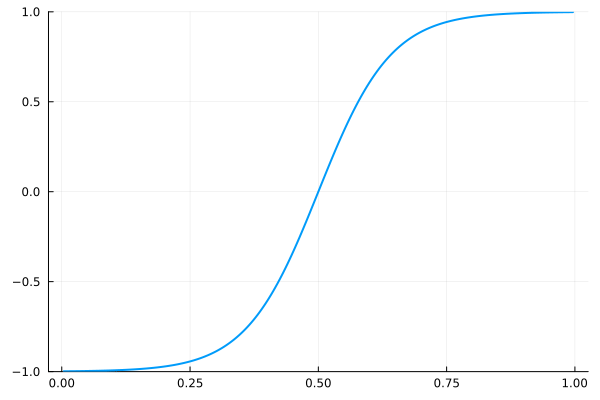

In [3]:
@gif for i in 1:length(u_ref.t)
    plot(x, u_ref.u[i], lw=2, ylim=(-1,1), label="")
end every 64

# Training NN FE

## Neural PDE training

In [4]:
include("../helper_functions/integration_AC.jl")

run_full_optimization

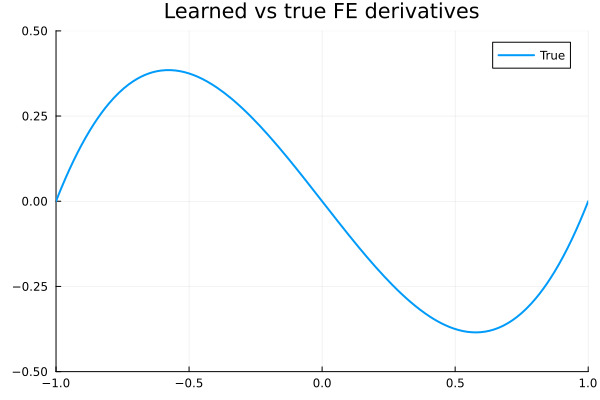

In [5]:
f_true(u) = u^3 - u
plot(u -> f_true(u), xlim=(-1,1), ylim=(-0.5,0.5), lw=2, label="True", title="Learned vs true FE derivatives")

In [6]:
(;prob,p₀,t_obs) = prepare_for_optimization()


(prob = ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, ComponentVector{Float64, Vector{Float64}, Tuple{Axis{(ε2 = 1, Δx = 2, θ = ViewAxis(3:99, Axis(layer_1 = ViewAxis(1:16, Axis(weight = ViewAxis(1:8, ShapedAxis((8, 1))), bias = ViewAxis(9:16, Shaped1DAxis((8,))))), layer_2 = ViewAxis(17:88, Axis(weight = ViewAxis(1:64, ShapedAxis((8, 8))), bias = ViewAxis(65:72, Shaped1DAxis((8,))))), layer_3 = ViewAxis(89:97, Axis(weight = ViewAxis(1:8, ShapedAxis((1, 8))), bias = ViewAxis(9:9, Shaped1DAxis((1,))))))))}}}, ODEFunction{true, SciMLBase.AutoSpecialize, var"#neural_ODE_prob##2#neural_ODE_prob##3"{Chain{@NamedTuple{layer_1::Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, @NamedTuple{layer_1::@NamedTuple{}, layer_2::@NamedTuple{}, layer_3::@NamedTuple{}}}, UniformScaling{Bool}, Nothing, Nothing, N

In [7]:
optprob = set_up_optimization(u_ref,prob,t_obs,p₀)

OptimizationProblem. In-place: true
u0: 97-element Vector{Float64}:
  2.2779722213745117
  2.6323390007019043
  1.7331405878067017
 -1.020883321762085
  2.538412094116211
 -1.9881163835525513
 -0.9291045069694519
 -0.21118351817131042
 -0.5329763889312744
 -0.16852331161499023
  ⋮
  0.19251060485839844
 -0.23106054961681366
  0.26776111125946045
  0.18144285678863525
 -0.20919865369796753
 -0.26119092106819153
  0.17437100410461426
  0.24217239022254944
  0.24197660386562347

In [8]:
result = run_full_optimization(optprob)

Optimization Params: η = 0.05; β = (0.9, 0.99); N_iter = 400
Warming up


┌ Warning: Lux.apply(m::AbstractLuxLayer, x::AbstractArray{<:ReverseDiff.TrackedReal}, ps, st) input was corrected to Lux.apply(m::AbstractLuxLayer, x::ReverseDiff.TrackedArray}, ps, st).
│ 
│ 1. If this was not the desired behavior overload the dispatch on `m`.
│ 
│ 2. This might have performance implications. Check which layer was causing this problem using `Lux.Experimental.@debug_mode`.
└ @ ArrayInterfaceReverseDiffExt /Users/milesgantcher/.julia/packages/LuxCore/kQC9S/ext/ArrayInterfaceReverseDiffExt.jl:9


Warmup Complete

Beginning Optimization

iteration = 10, loss = 0.043800884367366524, last iteration = 0.58 s
iteration = 20, loss = 0.03332538203947979, last iteration = 0.59 s
iteration = 30, loss = 0.0036766908066474613, last iteration = 0.51 s
iteration = 40, loss = 0.004363589450556612, last iteration = 0.59 s
iteration = 50, loss = 0.0016372828131171319, last iteration = 0.62 s
iteration = 60, loss = 0.001501318269972083, last iteration = 0.6 s
iteration = 70, loss = 0.0008949337049082282, last iteration = 0.58 s
iteration = 80, loss = 0.0008004801029153071, last iteration = 0.53 s
iteration = 90, loss = 0.0006799921859326977, last iteration = 0.82 s
iteration = 100, loss = 0.0005802728954822748, last iteration = 0.54 s
iteration = 110, loss = 0.0005071652087454723, last iteration = 0.49 s
iteration = 120, loss = 0.00045458664123337026, last iteration = 0.5 s
iteration = 130, loss = 0.0004191263609449533, last iteration = 0.87 s
iteration = 140, loss = 0.0003958824842175894, last

retcode: Default
u: 97-element Vector{Float64}:
  2.530757572078271
  2.7666312726398075
  1.41436764560351
 -1.1057538434421998
  2.3905563880740894
 -1.6570744716234354
 -1.3307833341708886
  0.24938112998792586
 -0.26773892136029176
 -0.35805762081824893
  ⋮
  0.15487748804435722
  0.03143636565137483
  0.24768366275171302
 -0.010205803707684806
  0.205031386803785
 -0.07617410289598228
  0.17597876907287194
  0.27911588341885546
  0.1956979913778233

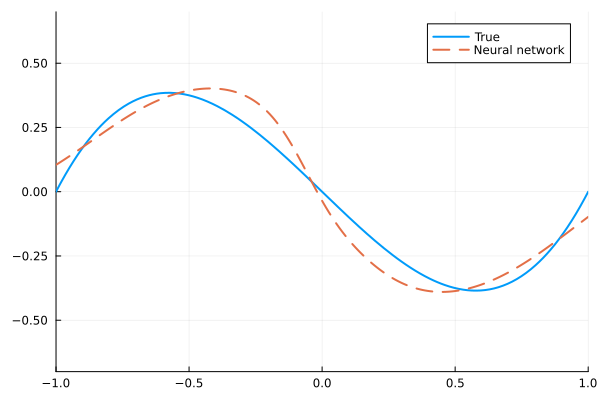

In [16]:
nn = prob.f.f.nn
state = prob.f.f.state

θ_opt = result.u
_, re = Optimisers.destructure(p₀.θ)
ps_opt = re(θ_opt)

us = range(-1, 1; length=200)
Fvals = [Fnn(u, nn, ps_opt, state) for u in us]

plot(
    u -> u^3 - u;
    xlim=(-1, 1),
    ylim=(-0.7, 0.7),
    lw=2,
    label="True",
)

plot!(us, Fvals;
    lw=2,
    label="Neural network",
    ls=:dash,
)